# 01 — EDA Overview

**RouteIQ — Delivery Operations Analytics**

This notebook is a JupyterLab presentation of the already-approved Phase 4
Python EDA (`python/analysis/01_eda_overview.py`). It does not introduce any
new calculation, statistical methodology, or finding — every number and
chart here reproduces, from `data/cleaned/cleaned_delivery.csv`, what is
already documented in `reports/python_eda_report.md` and
`output/eda_summary.json`.

**Business question:** What does the RouteIQ delivery dataset look like at
a glance — volume, time span, dimensions, and the overall shape of the core
outcome measure (`Delivery_Time`)?

**Data used:** `data/cleaned/cleaned_delivery.csv` (43,648 rows), the
approved, frozen Phase 1 output. Read-only throughout — this notebook never
regenerates or modifies it.


In [1]:
from _nb_theme import setup_paths, apply_theme, NAVY, TEAL, CORAL, NEUTRAL_SEQUENCE, annotate_bars, sample_size_caption
project_root = setup_paths()
apply_theme()

import sys
import importlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

from _common import load_cleaned_data

pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
df = load_cleaned_data()
print(f"Loaded {len(df):,} rows, {df.shape[1]} columns from data/cleaned/cleaned_delivery.csv")


2026-08-17 14:25:08 | INFO     | routeiq_phase4 | Logging initialized. Log file: C:\Data Analyst Projects\RouteIQ Project\logs\phase1_pipeline_20260817_142508.log


2026-08-17 14:25:09 | INFO     | routeiq_phase4 | Loaded approved cleaned dataset: 43648 rows, 30 columns


Loaded 43,648 rows, 30 columns from data/cleaned/cleaned_delivery.csv


## 1. Dataset Overview

**Analysis performed:** basic shape, date coverage, and dimension
cardinalities — the same figures documented in `reports/python_eda_report.md`
§1, computed fresh here directly from the loaded DataFrame.


In [2]:
date_min, date_max = pd.to_datetime(df["Order_Date"]).min(), pd.to_datetime(df["Order_Date"]).max()
distinct_dates = pd.to_datetime(df["Order_Date"]).nunique()

overview = pd.Series({
    "Total deliveries": len(df),
    "Distinct Order_IDs": df["Order_ID"].nunique(),
    "Date range start": date_min.date(),
    "Date range end": date_max.date(),
    "Distinct calendar dates observed": distinct_dates,
    "Distinct product categories": df["Category"].nunique(),
    "Distinct area types": df["Area"].nunique(),
    "Distinct weather conditions": df["Weather"].nunique(),
    "Distinct traffic levels": df["Traffic"].nunique(),
    "Distinct vehicle types": df["Vehicle"].nunique(),
}, name="Value")
overview.to_frame()


,Value
Total deliveries,43648
Distinct Order_IDs,43648
Date range start,2022-02-11
Date range end,2022-04-06
Distinct calendar dates observed,44
Distinct product categories,16
Distinct area types,4
Distinct weather conditions,6
Distinct traffic levels,4
Distinct vehicle types,3


**Key observation:** 43,648 deliveries across a ~8-week window (11 Feb – 06
Apr 2022), 16 product categories, 4 area types, 6 weather conditions, 4
traffic levels, and 3 vehicle types present in the cleaned data.

**Limitation:** Only 3 vehicle types appear — `bicycle` is documented as
having 0 rows post-cleaning (all 15 raw rows fell inside the Cleaning Step 3
exclusion cluster). This is absence, not a data gap to fill in.


## 2. Delivery Time Distribution

**Business question:** What is the overall shape of `Delivery_Time` —
central tendency, spread, and percentiles?

**Analysis performed:** reuses `describe_delivery_time()` from the approved
`01_eda_overview.py` module directly (imported below, not reimplemented).


In [3]:
m1 = importlib.import_module("01_eda_overview")
dist_stats = m1.describe_delivery_time(df)
pd.DataFrame([
    {"min": dist_stats["min"], "max": dist_stats["max"], "mean": dist_stats["mean"],
     "median": dist_stats["median"], "std": dist_stats["std"], "skewness": dist_stats["skewness"],
     **dist_stats["percentiles"]}
])


2026-08-17 14:25:09 | INFO     | routeiq_phase4 | Overall delivery time: mean=124.91 median=125.0 std=51.93 skew=0.1884


,min,max,mean,median,std,skewness,p50,p75,p90,p95
0,10.0000,270.0000,124.9100,125.0000,51.9300,0.1884,125.0000,160.0000,195.0000,215.0000


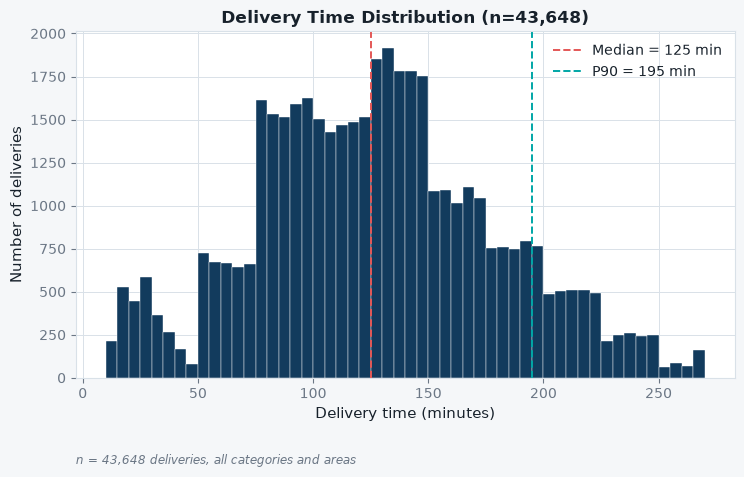

In [4]:
median = dist_stats["median"]
p90 = dist_stats["percentiles"]["p90"]

fig, ax = plt.subplots(figsize=(8.5, 4.5))
ax.hist(df["Delivery_Time"], bins=52, color=NAVY, edgecolor="white", linewidth=0.3)
ax.axvline(median, color=CORAL, linestyle="--", linewidth=1.4, label=f"Median = {median:.0f} min")
ax.axvline(p90, color=TEAL, linestyle="--", linewidth=1.4, label=f"P90 = {p90:.0f} min")
ax.set_title(f"Delivery Time Distribution (n={len(df):,})")
ax.set_xlabel("Delivery time (minutes)")
ax.set_ylabel("Number of deliveries")
ax.legend()
sample_size_caption(ax, f"n = {len(df):,} deliveries, all categories and areas")
plt.show()


**Key observation:** The distribution is bimodal-looking rather than a
single smooth peak — a low cluster (~10–55 min, where `Grocery`'s much
shorter delivery-time scale sits) and a broader main cluster (~75–270 min
covering the other 15 categories). Mean (124.91 min) and median (125.0 min)
are close, consistent with the mild right skew (0.1884).

**Limitation:** This is a pooled, cross-category histogram — `Grocery`'s
different fulfillment profile (see notebook 02) is a known, documented
reason for the bimodal shape, not a data-quality issue.


## 3. SLA Breach Distribution

**Business question:** How is the (frozen, never-recalculated) SLA breach
flag distributed overall and across the illustrative `delivery_bucket`
bins?

**Analysis performed:** reuses `sla_breach_distribution()` from
`01_eda_overview.py` — reads `sla_breach_flag` exactly as stored.


In [5]:
breach_dist = m1.sla_breach_distribution(df)
print(f"Overall SLA breach rate: {breach_dist['overall_breach_rate_pct']:.4f}%")
bucket_df = pd.DataFrame(breach_dist["by_delivery_bucket"]).T
bucket_df.index.name = "delivery_bucket"
bucket_df


2026-08-17 14:25:10 | INFO     | routeiq_phase4 | Overall SLA breach rate: 23.6620%


Overall SLA breach rate: 23.6620%


,n,breach_rate
delivery_bucket,,
0-60 minutes,"4,720.0000",13.1400
121-180 minutes,"15,945.0000",20.7400
181+ minutes,"6,401.0000",100.0000
61-120 minutes,"16,582.0000",0.0000


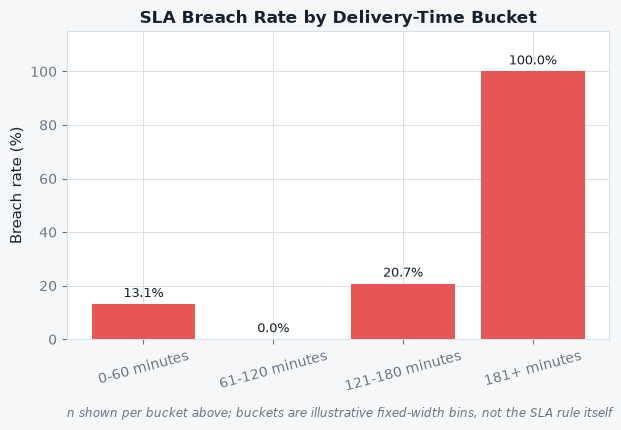

In [6]:
order = ["0-60 minutes", "61-120 minutes", "121-180 minutes", "181+ minutes"]
bucket_df = bucket_df.loc[order]

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(bucket_df.index, bucket_df["breach_rate"], color=CORAL)
annotate_bars(ax, bars, fmt="{:.1f}%", offset=1.5)
ax.set_ylim(0, 115)
ax.set_title("SLA Breach Rate by Delivery-Time Bucket")
ax.set_ylabel("Breach rate (%)")
ax.tick_params(axis="x", rotation=15)
sample_size_caption(ax, "n shown per bucket above; buckets are illustrative fixed-width bins, not the SLA rule itself")
plt.show()


**Key observation:** This pattern is mechanical, not a new finding: most
category thresholds sit at 160 or 165 minutes (P75 of a ~125-min median
distribution), so almost nothing in the 61–120 bucket can exceed its
threshold (0.00% breach), and almost everything at 181+ minutes necessarily
does (100.00%). The buckets illustrate how fixed-width bins relate to the
frozen, category-specific thresholds — they are not a separate breach rule.

**Limitation:** `delivery_bucket` is a fixed-width illustrative bin, not
part of the SLA methodology. The actual breach rule is always
`Delivery_Time > sla_threshold_minutes` at the category level (see notebook
03).


## 4. Outlier Analysis (descriptive only)

**Business question:** Are there statistical outliers in `Delivery_Time`,
and are they data-quality issues or genuine extreme deliveries?

**Analysis performed:** reuses `outlier_analysis()` from `01_eda_overview.py`
— a per-category Tukey 1.5×IQR rule (a global IQR would mislabel `Grocery`'s
entire distribution, given its different scale). **No row is removed or
modified** — this only characterizes what already exists in the approved,
cleaned dataset.


In [7]:
outliers = m1.outlier_analysis(df)
print(f"Total statistical outliers: {outliers['total_statistical_outliers']} "
      f"({outliers['total_outliers_pct_of_dataset']}% of dataset)")
print(f"  co-occurring with a known Phase 1 data-quality flag: "
      f"{outliers['outliers_co_occurring_with_a_known_data_quality_flag']}")
print(f"  no known data-quality flag (valid extreme deliveries): "
      f"{outliers['outliers_with_no_known_data_quality_flag_valid_extreme_deliveries']}")
pd.DataFrame(outliers["per_category"]).T


2026-08-17 14:25:11 | INFO     | routeiq_phase4 | Outlier analysis: 143 statistical outliers (0.328% of dataset), 12 co-occur with a known data-quality flag, 131 are unflagged (valid extreme)


Total statistical outliers: 143 (0.328% of dataset)
  co-occurring with a known Phase 1 data-quality flag: 12
  no known data-quality flag (valid extreme deliveries): 131


,n,iqr_lower_bound,iqr_upper_bound,statistical_outliers
Apparel,"2,722.0000",-10.0000,270.0000,0.0000
Books,"2,817.0000",-2.5000,257.5000,8.0000
Clothing,"2,662.0000",-2.5000,257.5000,14.0000
Cosmetics,"2,670.0000",-10.0000,270.0000,0.0000
Electronics,"2,843.0000",-2.5000,257.5000,10.0000
Grocery,"2,688.0000",-2.0000,54.0000,0.0000
Home,"2,680.0000",-2.5000,257.5000,17.0000
Jewelry,"2,796.0000",-2.5000,257.5000,19.0000
Kitchen,"2,667.0000",-10.0000,270.0000,0.0000
Outdoors,"2,741.0000",-2.5000,257.5000,11.0000


**Key observation:** 143 statistical outliers (0.328% of the dataset); 12
co-occur with an already-known Phase 1 data-quality flag (invalid
coordinates, out-of-range/null rating, or implausible age), and 131 carry no
such flag — these are treated as valid extreme deliveries, not errors,
consistent with the project's documented outlier strategy (the long tail is
exactly what P90 tracking exists for).

**Limitation:** Descriptive only. No row was removed or altered — the
approved cleaned dataset is unmodified.


## 5. Missingness / Exclusion-Flag Summary

**Business question:** How many rows are excluded from which
attribute-specific analyses, and why?

**Analysis performed:** reuses `missingness_exclusion_summary()` — a
restatement of Phase 1's exclusion flags, not a re-cleaning step.


In [8]:
missingness = m1.missingness_exclusion_summary(df)
pd.Series(missingness, name="rows_excluded").to_frame()


,rows_excluded
agent_rating_available_flag_false,54
agent_rating_valid_flag_false,54
agent_age_valid_flag_false,0
coordinates_valid_flag_false,3651
area_tier_valid_flag_false,1136


**Key observation:** 54 rows have no agent rating at all (excluded from
rating-based analysis); 3,651 rows have invalid coordinates (excluded from
distance analysis); 1,136 rows are area type `Other` (excluded from
Urban/Metropolitian/Semi-Urban tier comparisons, never dropped entirely).

**Limitation:** These are pre-existing Phase 1 flags, applied consistently
across every notebook in this project — no new exclusion rule is introduced
here.

---

**Next:** [`02_delivery_time_analysis.ipynb`](02_delivery_time_analysis.ipynb) —
how delivery time varies by area, category, weather, traffic, vehicle, and
day type.
